In [2]:
# libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import json


import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib import cm


from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance



In [3]:
labels = [# 'human',
          'gpt_5.1',
          'gpt_5.4',
          'gpt_5.4_mini',
          'gpt_5.4_nano',
          'Llama_3.3_70B_Instruct',
          'Gemma_4_31B',
          'Qwen3.5_27B',
          'Qwen3.5_9B',
          ]

In [4]:
# parameters of file
task = 'cg'
values = [0, 140]
v = 1
n = 3

framed = False

In [5]:
project_dir = os.path.abspath("..")

In [6]:
support = np.arange(1,7)
take = 'X'

In [7]:
path_to_human_svo_profiles = os.path.join(project_dir, 'data', 'human_svo_profiles_beta.csv')
human_svo_profiles = pd.read_csv(path_to_human_svo_profiles)
human_svo_profiles['svo'] = human_svo_profiles['svo'].astype(int)
human_svo_profiles['frequency'] = human_svo_profiles['count'] / human_svo_profiles['count'].sum()


assert np.isclose(human_svo_profiles['frequency'].sum(), 1.)

In [8]:
n=3

res = {}

whole_dataset = {}
for value in values:
    ress = {}
    
    whole_data = []
    for label in labels:
        for bl in ['blinded', 'unblinded']:
            file_name = f'{label}-cg-{value}-v{v}-n{n}-{bl}-framed-seq-explicit.json'  ### only blinded
            
            path_to_file = os.path.join(project_dir, 'output', file_name)
            with open(path_to_file, encoding='utf-8') as f:
                 data = json.load(f)
                
            take_results = {}
            for svo, output in data.items():
            
                take_probability = np.zeros(len(support), dtype=float)
                for role in ['A', 'B']:
                    for k, sample_dict_list in output[f'role{role}'].items():
                        # print(k, '\n')
                        mean_take_values = []
                        # std_take_values = []
                        for sample_dict in sample_dict_list:
                            # print(sample_dict)
                            take_values = []
                            for sample, sample_values in sample_dict.items():
                                # print(sample, sample_values)
                                if sample_values['X'] is None and sample_values['Y'] is None:
                                    print(f'both values are nans so we skip them, {label}, {value} {bl}')
                                    # sample_values['X'] = .5
                                    # sample_values['Y'] = .5
                                else:
                                    if sample_values['X'] is None:
                                        # print('X is nan so we set it to 1-Y')
                                        sample_values['X'] = 1 - sample_values['Y']
                                    elif sample_values['Y'] is None:
                                        # print('Y is nan so we set it to 1-X')
                                        sample_values['Y'] = 1 - sample_values['X']
                                        
                                    sample_values['X'] =np.clip(sample_values['X'], 0, 1)
                                    sample_values['Y'] =np.clip(sample_values['Y'], 0, 1)
                                    
                                    somma = sample_values['X'] + sample_values['Y']
                                    sample_values['X'] /= somma
                                    sample_values['Y'] /= somma
                                    take_values.append(sample_values[take])
                            mean_take_values.append(np.mean(take_values))
                            
                        take_probability[int(k)-1] = np.mean(mean_take_values)
                        
                    
                take_results[int(svo)] = take_probability
                
                whole_data.append([int(svo)]+list(take_probability))
                        
                
                    
        results_df = pd.DataFrame(take_results).T
        results_df.index.name = "svo"
        results_df = results_df.sort_index()
        ress[label] = results_df
        
    res[value] = ress
    whole_dataset[value] = whole_data
        
            
            
            
            
        

both values are nans so we skip them, Qwen3.5_9B, 0 blinded
both values are nans so we skip them, Qwen3.5_9B, 140 blinded
both values are nans so we skip them, Qwen3.5_9B, 140 blinded


In [9]:

results_df

,0,1,2,3,4,5
svo,,,,,,
-16,0.434489,0.964281,0.897090,0.970688,0.914901,0.955398
-15,0.407333,0.965500,0.904651,0.954140,0.917981,0.941882
-10,0.417497,0.946597,0.810119,0.934940,0.904651,0.946597
-8,0.378496,0.952574,0.840493,0.946597,0.916635,0.941104
-7,0.358277,0.898609,0.811112,0.916635,0.871623,0.889139
-6,0.437823,0.924142,0.851953,0.929683,0.908067,0.937427
-5,0.397402,0.934656,0.816089,0.944369,0.880797,0.932453
-4,0.407333,0.916041,0.798187,0.932453,0.911484,0.954160
-3,0.348645,0.827599,0.750556,0.903533,0.880797,0.907704


0, 0
[-0.51103489 -0.02899655]


0, 1
[ 0.53661795 -0.02646106]


0, 2
[ 2.69613438 -0.03492549]


0, 3
[ 0.92105691 -0.00935266]


0, 4
[ 5.86806619 -0.02078525]


0, 5
[7.73507041 0.009634  ]


140, 0
[-0.54424235 -0.03123024]


140, 1
[ 0.5136688  -0.04182742]


140, 2
[ 2.46608283 -0.0493102 ]


140, 3
[ 0.40705634 -0.0207227 ]


140, 4
[ 3.27162329 -0.04483955]


140, 5
[ 0.46362737 -0.02873417]




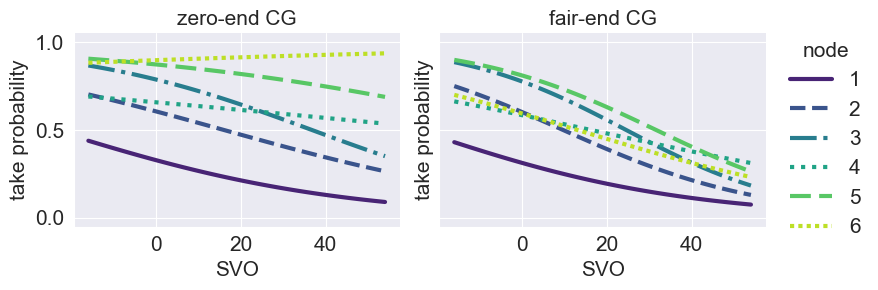

In [14]:
# from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

# Models to display on the y-axis
models = labels
treatments = {0: 'zero-end CG', 140: 'fair-end CG'}

colors = cm.viridis(np.linspace(0.1, 0.9, 6))
linestyles = ['-', '--', '-.', ':', (0, (5, 2)), (0, (1, 1))]
    





fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharex=True, sharey=True)

for i, value in enumerate(values):
    results_treatment = np.array(whole_dataset[value], dtype=float)
    
    sample_idx = np.random.randint(results_treatment.shape[0], size=70)
    
    for nn in range(6):
            
        x = results_treatment[:,0]
        y = results_treatment[:,nn+1]
        
        # Design matrix: intercept + x
        X = sm.add_constant(x)
        
        
        # Fractional logistic regression
        glm = sm.GLM(
            y,
            X,
            family=sm.families.Binomial(
                link=sm.families.links.Logit()
            )
        )
        
        result = glm.fit(cov_type="HC1")  # robust standard errors
        
        print(f'{value}, {nn}')
        # print(result.summary())
        
        print(np.exp(result.params)-1.)
        print('\n')
        
        # Smooth grid for fitted curve
        x_fit = np.linspace(x.min(), x.max(), 100)
        X_fit = sm.add_constant(x_fit)
        
        y_fit = result.predict(X_fit)
        
        axes[i].plot(x_fit, y_fit, color = colors[nn], label=str(nn+1), lw=3, linestyle = linestyles[nn])
        # axes[i].scatter(x[sample_idx], y[sample_idx], color = colors[nn], s=4, alpha=0.3)
        axes[i].set_xlabel('SVO', fontsize=15)
        axes[i].set_ylabel('take probability', fontsize=15)
        axes[i].set_title(f'{treatments[value]}', fontsize=15)
        axes[i].set_ylim(-0.05, 1.05)
        axes[i].grid(axis='y')
        axes[i].spines[["top", "right"]].set_visible(False)
        axes[i].tick_params(axis="both", which="major", labelsize=15)
    
        
        
    
axes[-1].legend(bbox_to_anchor=(1.05, 1.), loc=2, borderaxespad=0., frameon=False, fontsize=15, title='node', title_fontsize=15,)  



plt.tight_layout()
# 
name = f'res3-v{v}-n{n}.pdf'
path_to_fig = os.path.join(project_dir, 'figures', name)
plt.savefig(path_to_fig, format='pdf', bbox_inches='tight')

plt.show()

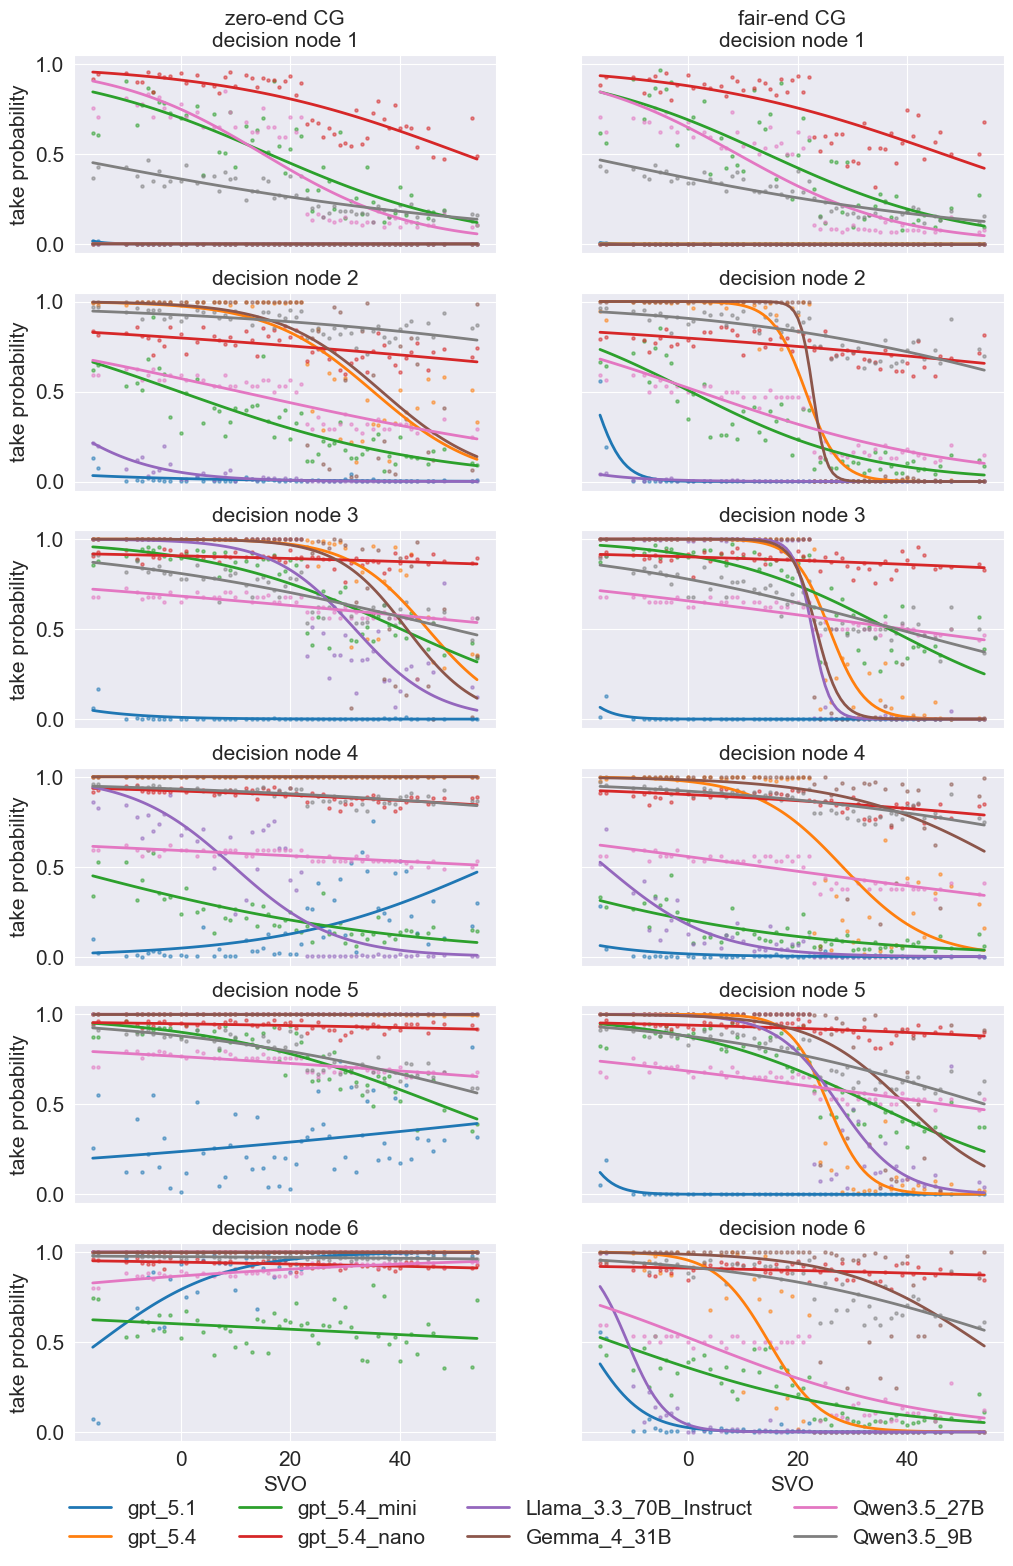

In [10]:
# from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

# Models to display on the y-axis
models = labels
treatments = {0: 'zero-end CG', 140: 'fair-end CG'}

colors = cm.tab10(range(len(models)))



fig, axes = plt.subplots(6, 2, figsize=(12,18), sharex=True, sharey=True)

for i, value in enumerate(values):
    results_treatment = res[value]
    
    for m, model in enumerate(models):
        results_model = results_treatment[model]
    
        for decision_node in range(6):
            
            series = results_model[decision_node]
            
            x = series.index.to_numpy(dtype=float)
            y = series.to_numpy(dtype=float)
            
            # Design matrix: intercept + x
            X = sm.add_constant(x)
            
            
            # Fractional logistic regression
            glm = sm.GLM(
                y,
                X,
                family=sm.families.Binomial(
                    link=sm.families.links.Logit()
                )
            )
            
            result = glm.fit(cov_type="HC1")  # robust standard errors
            
            # print(result.summary())
            
            # Smooth grid for fitted curve
            x_fit = np.linspace(x.min(), x.max(), 100)
            X_fit = sm.add_constant(x_fit)
            
            y_fit = result.predict(X_fit)
            
            axes[decision_node, i].plot(x_fit, y_fit, color = colors[m], label=model, lw=2)
            axes[decision_node,i].scatter(x, y, alpha=0.5, color = colors[m], s=5)
            
            axes[decision_node,i].tick_params(axis="both", which="major", labelsize=15)
            
            title = ''
            if decision_node == 0:
                title += f'{treatments[value]}\n'
            title += f'decision node {decision_node+1}'
            axes[decision_node,i].set_title(title, fontsize=15)
            
        
    
axes[-1,-1].legend(bbox_to_anchor=(1., -.2), frameon=False, fontsize=15, ncol=4,)  


for nn in range(6):
    axes[nn,0].set_ylabel('take probability', fontsize=15)
    
axes[-1, 0].set_xlabel('SVO', fontsize=15)
axes[-1, 1].set_xlabel('SVO', fontsize=15)
    




# plt.tight_layout()

name = f'res3-v{v}-n{n}-full.pdf'
path_to_fig = os.path.join(project_dir, 'figures', name)
plt.savefig(path_to_fig, format='pdf', bbox_inches='tight')

plt.show()